# 맨홀-노드 GNN 그래프 구성 v2 (관저고 기반 방향 보정)

**노드 = 맨홀, 엣지 = 관저고 기반 흐름방향 보정 유향 관거**. 기존 `08_manhole_graph`의 원본 구성은 유지하고,
이 노트북은 학습용 그래프 산출물(`node_idx`, `edge_index`, 방향 신뢰도 플래그)을 추가로 생성한다.


In [1]:

import os; os.chdir('/home/namjun/city_flood')
import sys; sys.path.insert(0,'scripts'); from krfont import set_korean; set_korean()
import geopandas as gpd, pandas as pd, numpy as np, networkx as nx, warnings
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
warnings.filterwarnings('ignore')
base="03_GIS/관악구_하수관로_맨홀_shp/"; EB="dataset/processed/eda_based/"
pipe=gpd.read_file(base+"sb001.shp")
p=pipe[pipe.sat_mhe.notna()&pipe.end_mhe.notna()&(pipe.sat_mhe.astype(str).str.strip()!='')&(pipe.end_mhe.astype(str).str.strip()!='')].copy()
p['pipe_id']=p.index.astype(str)
p['sat']=p.sat_mhe.astype(str).str.strip(); p['end']=p.end_mhe.astype(str).str.strip()
print("엣지화 가능 관거",len(p))


엣지화 가능 관거 16059


## 1. 노드(맨홀) — 좌표는 관거 끝점, 지반고/소배수구역 부착

In [2]:
# 노드 좌표 = 관거 geometry 끝점
coords={}
for _,r in p.iterrows():
    c=list(r.geometry.coords); coords.setdefault(r.sat,c[0]); coords.setdefault(r.end,c[-1])
nodes=pd.DataFrame([(k,v[0],v[1]) for k,v in coords.items()],columns=['node_id','x','y'])
# 지반고(hsl): sb101 맨홀에서 mhe_idn 매칭
mh=gpd.read_file(base+"sb101.shp")[['mhe_idn','hsl']].dropna(subset=['mhe_idn'])
mh['mhe_idn']=mh.mhe_idn.astype(str)
nodes=nodes.merge(mh.drop_duplicates('mhe_idn'),left_on='node_id',right_on='mhe_idn',how='left').drop(columns=['mhe_idn'])
# 소배수구역(swa_nam, cp949): 관거에서 노드로
def dec(x):
    try: return x.encode('latin1').decode('cp949')
    except: return x
p['swa']=p.swa_nam.map(dec)
swa=pd.concat([p[['end','swa']].rename(columns={'end':'node_id'}),p[['sat','swa']].rename(columns={'sat':'node_id'})]).dropna().drop_duplicates('node_id')
nodes=nodes.merge(swa,on='node_id',how='left')
print(f"노드 {len(nodes)} | 지반고 보유 {nodes.hsl.notna().mean():.0%} | 소배수구역 보유 {nodes.swa.notna().mean():.0%}")

노드 13272 | 지반고 보유 73% | 소배수구역 보유 100%


## 2. 엣지(유향 관거) — 관저고 기반 흐름방향 보정

공식 시작→끝 방향을 기본값으로 두되, 시작/끝 관저고가 모두 유효하고 경사가 반대인 관거는 흐름 방향을 뒤집어 저장한다. 결측·평탄 관거는 공식 방향을 유지하고 `direction_confidence`로 플래그 처리한다.


In [3]:

# 관거 유향 엣지 구성
# - 기본 방향은 공식 시작맨홀(sat_mhe)→끝맨홀(end_mhe)
# - 관저고(st_pip_hit, et_pip_hit)가 둘 다 유효하고 반대 경사면 방향을 뒤집어 저장
# - 결측/동일 관저고는 공식 방향을 유지하되 direction_confidence로 별도 표시
p['len']=pd.to_numeric(p.lenx,errors='coerce')
p['si']=pd.to_numeric(p.st_pip_hit,errors='coerce')
p['ei']=pd.to_numeric(p.et_pip_hit,errors='coerce')
p['length']=p['len'].where(p['len']>0)
p['raw_slope']=np.where((p.length>0)&(p.si>0)&(p.ei>0),(p.si-p.ei)/p.length,np.nan)
p['has_invert_elev']=(p.length>0)&(p.si>0)&(p.ei>0)&p.raw_slope.notna()
p['is_flat']=p.has_invert_elev & np.isclose(p.raw_slope,0)
p['is_reversed']=p.has_invert_elev & (p.raw_slope<0)
p['src']=np.where(p.is_reversed,p.end,p.sat)
p['dst']=np.where(p.is_reversed,p.sat,p.end)
p['flow_slope']=np.where(p.has_invert_elev,np.abs(p.raw_slope),np.nan)
p['direction_confidence']=np.select(
    [p.is_reversed, p.has_invert_elev & (p.raw_slope>0), p.is_flat],
    ['reversed_by_invert_elevation','official_matches_invert_elevation','flat_invert_keep_official'],
    default='official_only_missing_invert'
)
p['direction_source']=np.where(p.has_invert_elev,'invert_elevation','official_start_end')
edges=p[['pipe_id','sat','end','src','dst','length','raw_slope','flow_slope','is_reversed','direction_source','direction_confidence','swa']].copy()
edge_raw=len(edges)
edge_nx=edges.groupby(['src','dst'],as_index=False).agg(
    n_pipes=('pipe_id','count'),
    pipe_ids=('pipe_id',lambda s:'|'.join(map(str,s))),
    length=('length','sum'),
    mean_flow_slope=('flow_slope','mean'),
    min_flow_slope=('flow_slope','min'),
    max_flow_slope=('flow_slope','max'),
    reversed_count=('is_reversed','sum'),
    confidence_modes=('direction_confidence',lambda s:'|'.join(sorted(set(map(str,s))))),
    swa=('swa',lambda s: next((x for x in s if pd.notna(x)), np.nan)),
)
G=nx.from_pandas_edgelist(edge_nx,'src','dst',edge_attr=True,create_using=nx.DiGraph)
print(f"관거 레코드 {edge_raw} | 그래프 유니크 엣지 {len(edge_nx)} | 병렬/중복 병합 {edge_raw-len(edge_nx)}")
print(f"그래프: 노드 {G.number_of_nodes()} 엣지 {G.number_of_edges()} | DAG {nx.is_directed_acyclic_graph(G)} | 약연결성분 {nx.number_weakly_connected_components(G)}")
print("방향 판정:")
print(edges.direction_confidence.value_counts(dropna=False).to_string())
print(f"출구(토구 후보, out_degree=0) {sum(1 for _,d in G.out_degree() if d==0)}")


관거 레코드 16059 | 그래프 유니크 엣지 15260 | 병렬/중복 병합 799
그래프: 노드 13272 엣지 15260 | DAG False | 약연결성분 96
방향 판정:
direction_confidence
official_matches_invert_elevation    14688
reversed_by_invert_elevation          1047
flat_invert_keep_official              214
official_only_missing_invert           110
출구(토구 후보, out_degree=0) 823


## 3. 센서(수위계) → 맨홀 노드 snap (데이터 보유/신설 구분)

In [4]:

gs=gpd.read_file("03_GIS/하수관로_노면_수위계_shp/도시침수계(관로)_서울시 2026.shp")
gs['자치구']=gs['자치구'].astype(str); gs=gs[gs.자치구.str.contains('관악')].to_crs(5181)
have=set(pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id']).sensor_id)
tree=cKDTree(nodes[['x','y']].values)
sx=np.array([(g.x,g.y) for g in gs.geometry]); d,idx=tree.query(sx)
gs2=pd.DataFrame({'sensor_id':gs['수위계번호'].astype(str).values,'node_id':nodes.node_id.values[idx],'snap_m':d})
gs2['is_observed']=gs2.sensor_id.isin(have)
print(f"센서 {len(gs2)} snap(중앙 {np.median(d):.0f}m, p95 {np.percentile(d,95):.0f}m, 최대 {np.max(d):.0f}m) | 데이터 보유 {gs2.is_observed.sum()} / 신설 {(~gs2.is_observed).sum()}")
dup=gs2.node_id.value_counts(); dup=dup[dup>1]
print("센서 snap 같은 노드 충돌:", "없음" if dup.empty else dup.to_dict())
# 학습용 안정 인덱스 부여
nodes=nodes.merge(gs2[['node_id','sensor_id','is_observed','snap_m']],on='node_id',how='left')
nodes['is_sensor']=nodes.sensor_id.notna()
nodes=nodes.sort_values('node_id').reset_index(drop=True)
nodes['node_idx']=np.arange(len(nodes),dtype=np.int64)
node_idx=nodes.set_index('node_id').node_idx.to_dict()
edge_nx=edge_nx[edge_nx.src.isin(node_idx)&edge_nx.dst.isin(node_idx)].copy()
edge_nx['src_idx']=edge_nx.src.map(node_idx).astype(np.int64)
edge_nx['dst_idx']=edge_nx.dst.map(node_idx).astype(np.int64)
edge_index=edge_nx[['src_idx','dst_idx']].to_numpy().T
np.save(EB+"gnn_manhole_edge_index.npy",edge_index)
# 저장
nodes.to_parquet(EB+"gnn_manhole_nodes.parquet",index=False)
edges.to_parquet(EB+"gnn_manhole_edges_raw.parquet",index=False)
edge_nx.to_parquet(EB+"gnn_manhole_edges.parquet",index=False)
gs2.to_parquet(EB+"gnn_manhole_sensor_snap.parquet",index=False)
print("저장: gnn_manhole_nodes / gnn_manhole_edges_raw / gnn_manhole_edges / gnn_manhole_edge_index.npy / gnn_manhole_sensor_snap")


센서 42 snap(중앙 9m, p95 24m, 최대 29m) | 데이터 보유 13 / 신설 29
센서 snap 같은 노드 충돌: 없음
저장: gnn_manhole_nodes / gnn_manhole_edges_raw / gnn_manhole_edges / gnn_manhole_edge_index.npy / gnn_manhole_sensor_snap


## 4. 시각화 — 관망 그래프 + 센서 노드

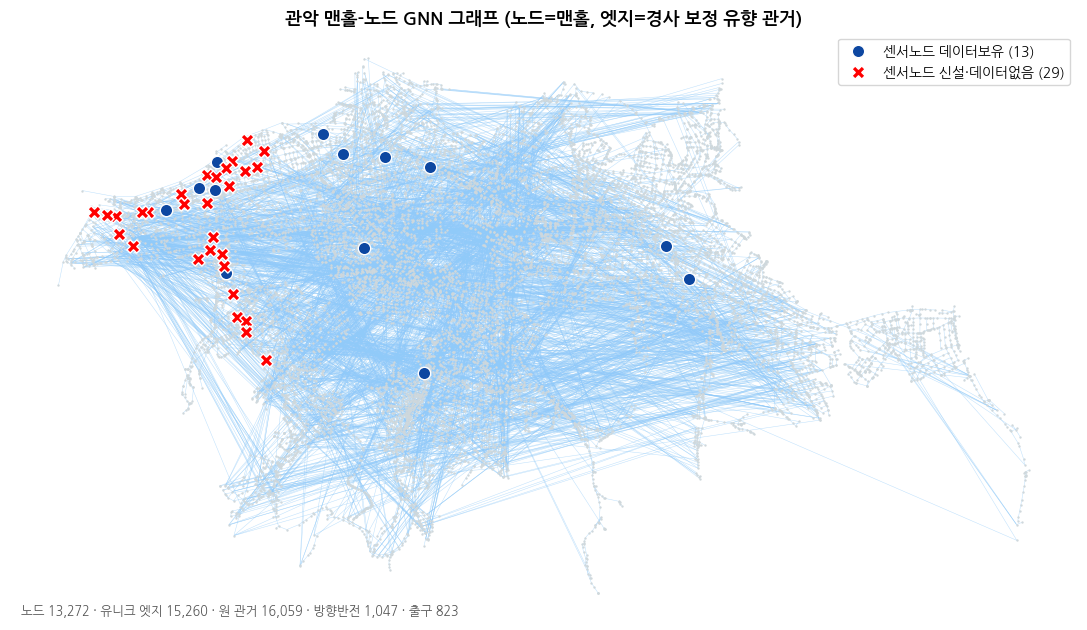

saved


In [5]:

fig,ax=plt.subplots(figsize=(11,9.5))
# 엣지(관거) 선: 모델 그래프는 src→dst 유향이지만, 그림은 과밀도를 피하려고 선으로 표시
seg=[]
nd=nodes.set_index('node_id')[['x','y']]
for _,e in edge_nx.iterrows():
    if e.src in nd.index and e.dst in nd.index:
        seg.append([(nd.loc[e.src,'x'],nd.loc[e.src,'y']),(nd.loc[e.dst,'x'],nd.loc[e.dst,'y'])])
from matplotlib.collections import LineCollection
ax.add_collection(LineCollection(seg,colors='#90caf9',linewidths=0.35,alpha=0.6,zorder=1))
ax.scatter(nodes.x,nodes.y,s=0.5,c='#cfd8dc',zorder=2)            # 맨홀
obs=nodes[(nodes.is_sensor==True)&(nodes.is_observed==True)]; new=nodes[(nodes.is_sensor==True)&(nodes.is_observed!=True)]
ax.scatter(obs.x,obs.y,s=80,c='#0d47a1',edgecolor='white',marker='o',zorder=5,label=f'센서노드 데이터보유 ({len(obs)})')
ax.scatter(new.x,new.y,s=90,c='red',edgecolor='white',marker='X',linewidths=1,zorder=5,label=f'센서노드 신설·데이터없음 ({len(new)})')
ax.set_title('관악 맨홀-노드 GNN 그래프 (노드=맨홀, 엣지=경사 보정 유향 관거)',fontsize=13,weight='bold')
ax.set_aspect('equal'); ax.set_axis_off(); ax.legend(fontsize=10,loc='upper right')
ax.text(0.01,0.01,
        f'노드 {len(nodes):,} · 유니크 엣지 {len(edge_nx):,} · 원 관거 {len(edges):,} · 방향반전 {int(edges.is_reversed.sum()):,} · 출구 {sum(1 for _,dd in G.out_degree() if dd==0)}',
        transform=ax.transAxes,fontsize=9,color='#555')
plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/10_manhole_graph.png',dpi=120,bbox_inches='tight'); plt.show(); print('saved')


## 결론
- **맨홀-노드 유향 그래프 구성 코드 보강**: 노드=맨홀(좌표·지반고·소배수구역), 엣지=관저고 기반 방향 보정 관거.
- 공식 시작→끝 방향과 관저고 흐름방향이 반대인 관거는 `is_reversed=True`로 뒤집고, 결측·평탄 관거는 공식 방향 유지 + `direction_confidence`로 추적.
- 원 관거 레코드(`gnn_manhole_edges_raw`)와 중복/병렬 집계 그래프 엣지(`gnn_manhole_edges`)를 분리 저장. PyG 연결용 `gnn_manhole_edge_index.npy`도 함께 저장.
- 센서 42개를 맨홀 노드에 snap하고, snap 거리 요약과 같은 노드 충돌을 출력. 관측 노드만 라벨(semi-supervised)로 사용 가능.
- 다음: 실제 관거 polyline 기반 보고서 그림 보강 + 노드 입력(맨홀별 강우 유입=강우×집수면적) 구성 — DEM·레이더 필요. 그 전엔 강우 균일가정으로 파이프라인 가동 가능.
